# Final Model Walkthrough

This notebook is a runnable handover walkthrough for the final integrated model. It follows the same structure as the report:

1. define the active 3D localisation task,
2. inspect the fixed biologically inspired pathway model,
3. inspect the cached pathway-feature vectors used by the trainable readout,
4. compare the fixed pathway readouts, direct SNN, residual SNN, and input-only SNN baselines,
5. display the main plots generated by the real experiment scripts.

The notebook uses the existing project code and saved artifacts under `final_model/outputs/`. It does not reimplement the model. By default it loads the full cached runs used for the report. If the caches are missing, or if `REGENERATE_FULL = True`, the notebook can call the real experiment scripts using `uv run --no-sync`.

## Runtime Modes

The full final readout experiments use 2000 training, 400 validation, and 400 test samples per acoustic condition, with 80 training epochs. Rebuilding everything is therefore slow.

The default mode below is:

- `REGENERATE_FULL = False`: load existing full cached outputs.
- `ALLOW_EXPENSIVE_REGENERATION_IF_MISSING = False`: fail with a clear message if a full cache is missing.

For a fresh machine, set `ALLOW_EXPENSIVE_REGENERATION_IF_MISSING = True` after installing the project dependencies. The notebook will then rebuild missing artifacts through the real scripts.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

try:
    import pandas as pd
except Exception:  # pragma: no cover - notebook fallback
    pd = None

# Locate repository root whether the notebook is run from the repo root or from final_model/notebooks.
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'final_model').exists():
    ROOT = ROOT.parent
if not (ROOT / 'final_model').exists():
    raise RuntimeError('Could not locate repository root containing final_model/')

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Keep uv/matplotlib caches inside writable temporary directories when running in restricted environments.
os.environ.setdefault('UV_CACHE_DIR', '/private/tmp/uv-cache')
os.environ.setdefault('MPLBACKEND', 'Agg')
os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '/private/tmp')

REGENERATE_FULL = False
ALLOW_EXPENSIVE_REGENERATION_IF_MISSING = False

print(f'Repository root: {ROOT}')

Repository root: /Users/jackhenry/Library/CloudStorage/OneDrive-UniversityofCambridge/IIB Project work/Offline_copy/Radar_SNN_4


## Helper Functions

These helpers keep the notebook concise. The important point is that regeneration calls the existing scripts in `final_model/experiments/`; analysis cells then load the generated JSON/NPZ artifacts.

In [2]:
def run_uv_python(script: str, *args: str) -> None:
    """Run one project script using uv without dependency syncing."""
    command = ['uv', 'run', '--no-sync', 'python', script, *args]
    env = os.environ.copy()
    env.setdefault('UV_CACHE_DIR', '/private/tmp/uv-cache')
    env.setdefault('MPLBACKEND', 'Agg')
    env.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
    env.setdefault('XDG_CACHE_HOME', '/private/tmp')
    print('Running:', ' '.join(command))
    subprocess.run(command, cwd=ROOT, env=env, check=True)


def load_json(path: str | Path) -> dict[str, Any]:
    path = Path(path)
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


def load_npz(path: str | Path) -> np.lib.npyio.NpzFile:
    return np.load(Path(path), allow_pickle=True)


def maybe_dataframe(rows: list[dict[str, Any]], index: str | None = None):
    if pd is None:
        return rows
    df = pd.DataFrame(rows)
    if index is not None and index in df.columns:
        df = df.set_index(index)
    return df


def display_png(path: str | Path, width: int | None = None) -> None:
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f'**Missing figure:** `{path}`'))


def ensure_file(path: str | Path, command: list[str] | None = None) -> None:
    """Ensure an artifact exists, optionally regenerating it with the supplied command."""
    path = Path(path)
    if path.exists() and not REGENERATE_FULL:
        return
    if command is None:
        raise FileNotFoundError(path)
    if not (REGENERATE_FULL or ALLOW_EXPENSIVE_REGENERATION_IF_MISSING):
        raise FileNotFoundError(
            f'{path} is missing. Set ALLOW_EXPENSIVE_REGENERATION_IF_MISSING = True '
            'or REGENERATE_FULL = True to rebuild it with the real experiment scripts.'
        )
    run_uv_python(*command)


def metric_row(label: str, metrics: dict[str, float]) -> dict[str, Any]:
    return {
        'model': label,
        'distance MAE (m)': metrics.get('distance_mae_m'),
        'azimuth MAE (deg)': metrics.get('azimuth_mae_deg'),
        'elevation MAE (deg)': metrics.get('elevation_mae_deg'),
        'Euclidean MAE (m)': metrics.get('euclidean_mae_m'),
        'combined error': metrics.get('combined_normalised_error'),
    }

## Artifact Checks And Optional Regeneration

This cell checks the main final outputs. The commands mirror the original scripts:

- `final_model_results.py`: fixed integrated pathway model.
- `trainable_final_readout.py`: fixed, direct SNN, and residual SNN pathway-feature readouts.
- `trainable_input_baselines.py`: raw-waveform and cochlear-raster SNN controls.

The full trainable runs are the report-scale runs. They are intentionally not regenerated unless requested.

In [3]:
ARTIFACTS = {
    'fixed_model_results': Path('final_model/outputs/final_model_results/results.json'),
    'clean_readout_results': Path('final_model/outputs/trainable_readout/results_train2000_val400_test400.json'),
    'noise_readout_results': Path('final_model/outputs/trainable_readout/results_train2000_val400_test400_envnoise50dB.json'),
    'reverb_readout_results': Path('final_model/outputs/trainable_readout/results_train2000_val400_test400_envnoise50dB_reverb.json'),
    'clean_readout_cache': Path('final_model/outputs/trainable_readout/cache_constrained_0p25_5m_pm45_train2000_val400_test400.npz'),
    'clean_readout_predictions': Path('final_model/outputs/trainable_readout/test_predictions_train2000_val400_test400.npz'),
    'clean_input_baseline_results': Path('final_model/outputs/trainable_input_baselines/results_train2000_val400_test400.json'),
    'noise_input_baseline_results': Path('final_model/outputs/trainable_input_baselines/results_train2000_val400_test400_envnoise50dB.json'),
    'reverb_input_baseline_results': Path('final_model/outputs/trainable_input_baselines/results_train2000_val400_test400_envnoise50dB_reverb.json'),
    'clean_input_baseline_cache': Path('final_model/outputs/trainable_input_baselines/cache_train2000_val400_test400.npz'),
}

# Fixed model result generation.
ensure_file(
    ARTIFACTS['fixed_model_results'],
    ['final_model/experiments/final_model_results.py'],
)

# Trainable pathway-feature readouts.
for label, args in [
    ('clean', []),
    ('environment noise', ['--environment-noise-db', '50']),
    ('noise plus delayed echoes', ['--environment-noise-db', '50', '--environment-reverb']),
]:
    result_key = {
        'clean': 'clean_readout_results',
        'environment noise': 'noise_readout_results',
        'noise plus delayed echoes': 'reverb_readout_results',
    }[label]
    ensure_file(
        ARTIFACTS[result_key],
        ['final_model/experiments/trainable_final_readout.py', '--train', '2000', '--val', '400', '--test', '400', '--epochs', '80', *args],
    )

# Input-only baselines.
for label, args in [
    ('clean', []),
    ('environment noise', ['--environment-noise-db', '50']),
    ('noise plus delayed echoes', ['--environment-noise-db', '50', '--environment-reverb']),
]:
    result_key = {
        'clean': 'clean_input_baseline_results',
        'environment noise': 'noise_input_baseline_results',
        'noise plus delayed echoes': 'reverb_input_baseline_results',
    }[label]
    ensure_file(
        ARTIFACTS[result_key],
        ['final_model/experiments/trainable_input_baselines.py', '--train', '2000', '--val', '400', '--test', '400', '--epochs', '80', *args],
    )

for name, path in ARTIFACTS.items():
    print(f'{name:32s} {"OK" if path.exists() else "MISSING"}  {path}')

fixed_model_results              OK  final_model/outputs/final_model_results/results.json
clean_readout_results            OK  final_model/outputs/trainable_readout/results_train2000_val400_test400.json
noise_readout_results            OK  final_model/outputs/trainable_readout/results_train2000_val400_test400_envnoise50dB.json
reverb_readout_results           OK  final_model/outputs/trainable_readout/results_train2000_val400_test400_envnoise50dB_reverb.json
clean_readout_cache              OK  final_model/outputs/trainable_readout/cache_constrained_0p25_5m_pm45_train2000_val400_test400.npz
clean_readout_predictions        OK  final_model/outputs/trainable_readout/test_predictions_train2000_val400_test400.npz
clean_input_baseline_results     OK  final_model/outputs/trainable_input_baselines/results_train2000_val400_test400.json
noise_input_baseline_results     OK  final_model/outputs/trainable_input_baselines/results_train2000_val400_test400_envnoise50dB.json
reverb_input_baseline_resul

## 1. Fixed Integrated Pathway Model

The fixed model runs the acoustic simulation, cochlea, distance pathway, azimuth pathway, elevation pathway, and SC-style CANN readouts without trainable final fusion. This is the model that establishes which cues are already extracted by the hand-designed pathways.

In [4]:
fixed_results = load_json(ARTIFACTS['fixed_model_results'])

rows = []
for condition_name, condition in fixed_results['conditions'].items():
    rows.append({
        'condition': condition_name,
        'samples': condition['num_samples'],
        **metric_row('fixed pathway/CANN', condition['metrics']),
    })

maybe_dataframe(rows, index='condition')

,samples,model,distance MAE (m),azimuth MAE (deg),elevation MAE (deg),Euclidean MAE (m),combined error
condition,,,,,,,
constrained,24,fixed pathway/CANN,0.031004,4.896113,0.809812,0.239356,0.044333
expanded,24,fixed pathway/CANN,0.555614,29.240187,2.770037,1.775530,0.137077


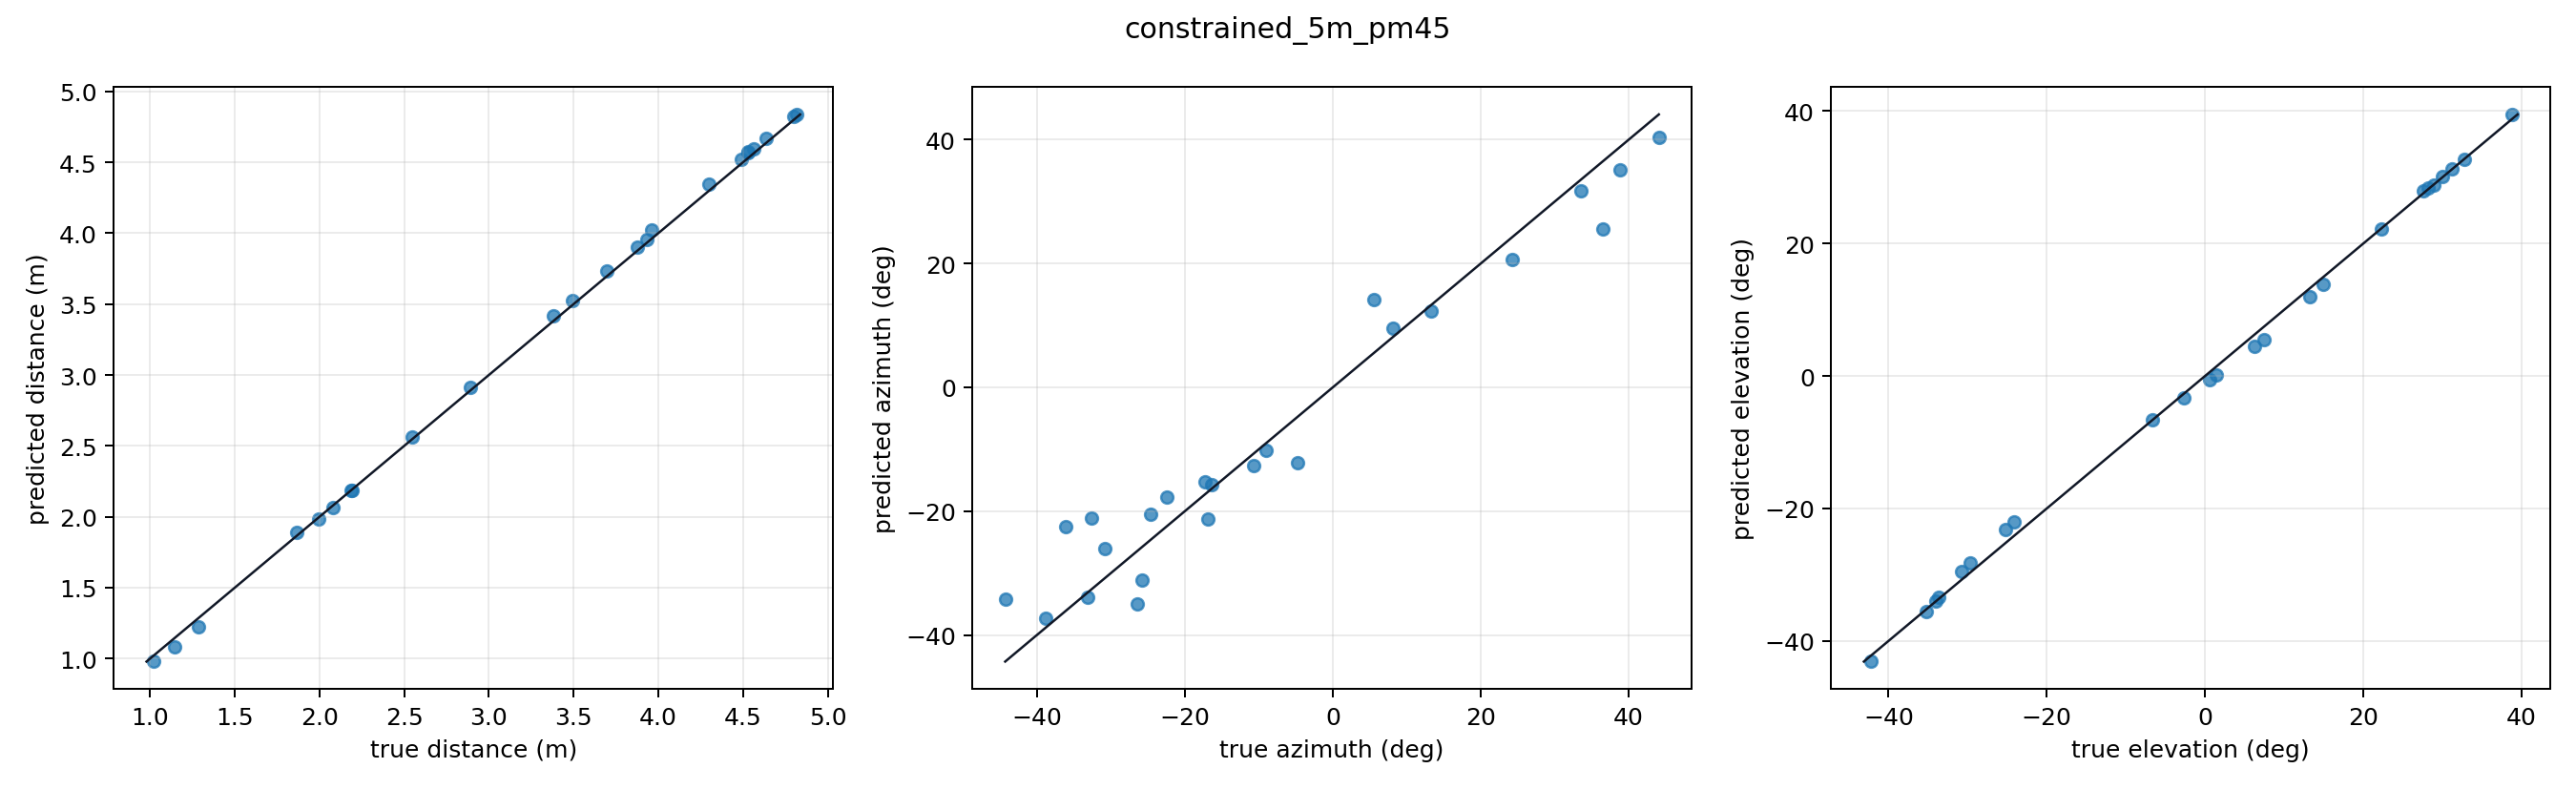

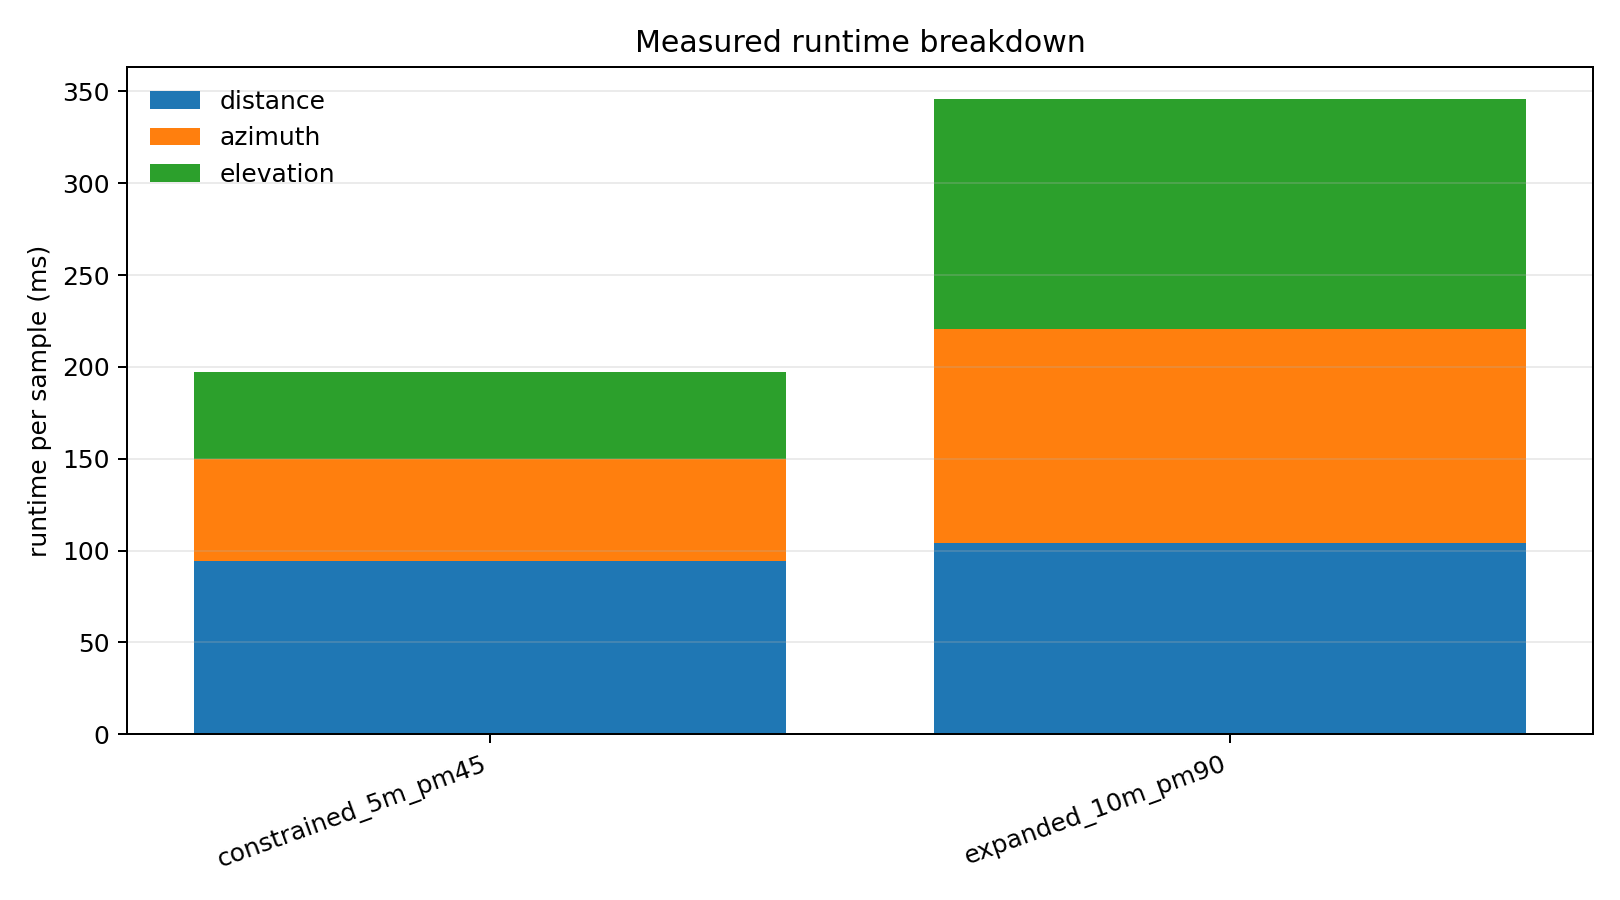

In [5]:
display_png('final_model/outputs/final_model_results/figures/constrained_predictions.png', width=900)
display_png('final_model/outputs/final_model_results/figures/runtime_breakdown.png', width=850)

## 2. Cached Pathway-Feature Vectors

The final trainable readout does not train directly from the raw waveform. It uses cached pathway features. For each sample, the feature vector contains:

- raw distance population,
- raw ITD azimuth population,
- raw ILD azimuth population,
- raw elevation population,
- three CANN coordinate readouts,
- confidence/statistical features.

This is the key representation tested in the report: structured biological features plus a small trainable SNN fusion layer.

In [6]:
readout_cache = load_npz(ARTIFACTS['clean_readout_cache'])
feature_groups = readout_cache['feature_groups'].item()
setup = readout_cache['setup'].item()

print('Feature matrix:', readout_cache['features'].shape)
print('Encoded targets:', readout_cache['targets_encoded'].shape)
print('Baseline coordinates:', readout_cache['baseline_coordinates'].shape)
print('True coordinates:', readout_cache['true_coordinates'].shape)
print('Feature seconds/sample:', float(readout_cache['feature_seconds_per_sample']))
print('Setup:', setup)

feature_rows = []
for name, (start, stop) in feature_groups.items():
    feature_rows.append({'group': name, 'start': start, 'stop': stop, 'width': stop - start})
maybe_dataframe(feature_rows, index='group')

Feature matrix: (2800, 474)
Encoded targets: (2800, 5)
Baseline coordinates: (2800, 3)
True coordinates: (2800, 3)
Feature seconds/sample: 0.628488578352678
Setup: {'distance_range_m': [0.25, 5.0], 'azimuth_range_deg': [-45.0, 45.0], 'elevation_range_deg': [-45.0, 45.0], 'channels': 48, 'distance_bins': 180, 'angular_bins': 91, 'splits': {'train': 2000, 'val': 400, 'test': 400}, 'dataset_seed': 8101}


,start,stop,width
group,,,
raw_distance_population,0,180,180
raw_azimuth_itd_population,180,271,91
raw_azimuth_ild_population,271,362,91
raw_elevation_population,362,453,91
cann_readouts,453,456,3
confidence_features,456,474,18


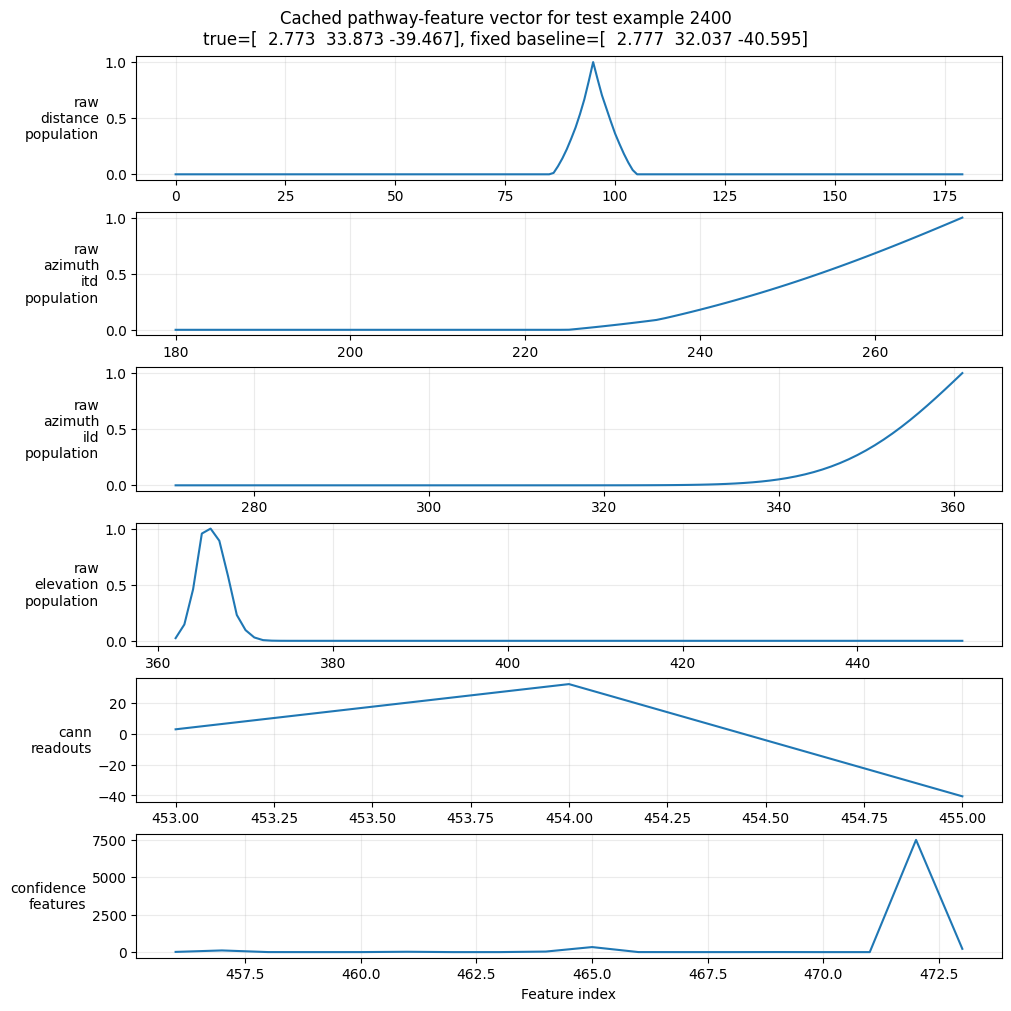

In [7]:
# Visualise one cached example as feature groups rather than as one opaque vector.
features = readout_cache['features']
split_names = readout_cache['split_names']
example_index = int(np.where(split_names == 'test')[0][0])
example = features[example_index]
true_xyz = readout_cache['true_coordinates'][example_index]
base_xyz = readout_cache['baseline_coordinates'][example_index]

fig, axes = plt.subplots(len(feature_groups), 1, figsize=(10, 10), constrained_layout=True)
for ax, (name, (start, stop)) in zip(axes, feature_groups.items()):
    ax.plot(np.arange(start, stop), example[start:stop], linewidth=1.5)
    ax.set_ylabel(name.replace('_', '\n'), rotation=0, ha='right', va='center')
    ax.grid(alpha=0.25)
axes[-1].set_xlabel('Feature index')
fig.suptitle(f'Cached pathway-feature vector for test example {example_index}\ntrue={true_xyz.round(3)}, fixed baseline={base_xyz.round(3)}')
plt.show()

## 3. Fixed, Direct SNN, And Residual SNN Readouts

The final pathway-feature experiment compares:

- `raw`: centre-of-mass decoding directly from raw pathway populations, without CANN.
- `baseline`: fixed calibrated/CANN pathway estimate.
- `direct`: SNN predicts coordinates directly from pathway features.
- `residual`: SNN starts from the fixed estimate and learns a correction.

The residual version is the main final model in the report.

In [8]:
readout_result_paths = {
    'clean': ARTIFACTS['clean_readout_results'],
    'environment noise': ARTIFACTS['noise_readout_results'],
    'noise + delayed echoes': ARTIFACTS['reverb_readout_results'],
}

readout_results = {name: load_json(path) for name, path in readout_result_paths.items()}
rows = []
for condition, payload in readout_results.items():
    for model_name, metrics in payload['test_metrics'].items():
        row = metric_row(model_name, metrics)
        row['condition'] = condition
        rows.append(row)

maybe_dataframe(rows, index='condition')

,model,distance MAE (m),azimuth MAE (deg),elevation MAE (deg),Euclidean MAE (m),combined error
condition,,,,,,
clean,raw,0.036511,4.580482,2.985793,0.299880,0.058481
clean,baseline,0.036600,4.924866,0.909951,0.243505,0.045661
clean,residual,0.013890,2.618797,0.266824,0.124747,0.022301
clean,direct,0.062355,2.449083,1.132638,0.161235,0.030688
environment noise,raw,0.078640,7.691454,29.980442,1.705447,0.284294
environment noise,baseline,0.078941,8.093637,26.641547,1.577239,0.262560
environment noise,residual,0.021310,3.705071,3.505242,0.296776,0.054830
environment noise,direct,0.068998,3.830542,4.018405,0.321357,0.062740
noise + delayed echoes,raw,0.079561,7.736485,28.961524,1.691657,0.277141


In [9]:
# Compact headline table: fixed CANN baseline vs direct and residual SNNs.
headline = []
for condition, payload in readout_results.items():
    for model_name in ['baseline', 'direct', 'residual']:
        row = metric_row(model_name, payload['test_metrics'][model_name])
        row['condition'] = condition
        headline.append(row)

df = maybe_dataframe(headline)
if pd is not None:
    display(pd.DataFrame(headline).set_index(['condition', 'model']).round(4))
else:
    display(headline)

distance MAE (m)  azimuth MAE (deg)  \
condition              model                                           
clean                  baseline            0.0366             4.9249   
                       direct              0.0624             2.4491   
                       residual            0.0139             2.6188   
environment noise      baseline            0.0789             8.0936   
                       direct              0.0690             3.8305   
                       residual            0.0213             3.7051   
noise + delayed echoes baseline            0.0799             8.1472   
                       direct              0.0731             3.8831   
                       residual            0.0202             3.8985   

                                 elevation MAE (deg)  Euclidean MAE (m)  \
condition              model                                              
clean                  baseline               0.9100             0.2435   
                       direct                 1.1326             0.1612   
                       residual               0.2668             0.1247   
environment noise      baseline              26.6415             1.5772   
                       direct                 4.0184             0.3214   
                       residual               3.5052             0.2968   
noise + delayed echoes baseline              25.9749             1.5674   
                       direct                 4.0283             0.3431   
                       residual               3.3405             0.3103   

                                 combined error  
condition              model                     
clean                  baseline          0.0457  
                       direct            0.0307  
                       residual          0.0223  
environment noise      baseline          0.2626  
                       direct            0.0627  
                       residual          0.0548  
noise + delayed echoes baseline          0.2581  
                       direct            0.0635  
                       residual          0.0550

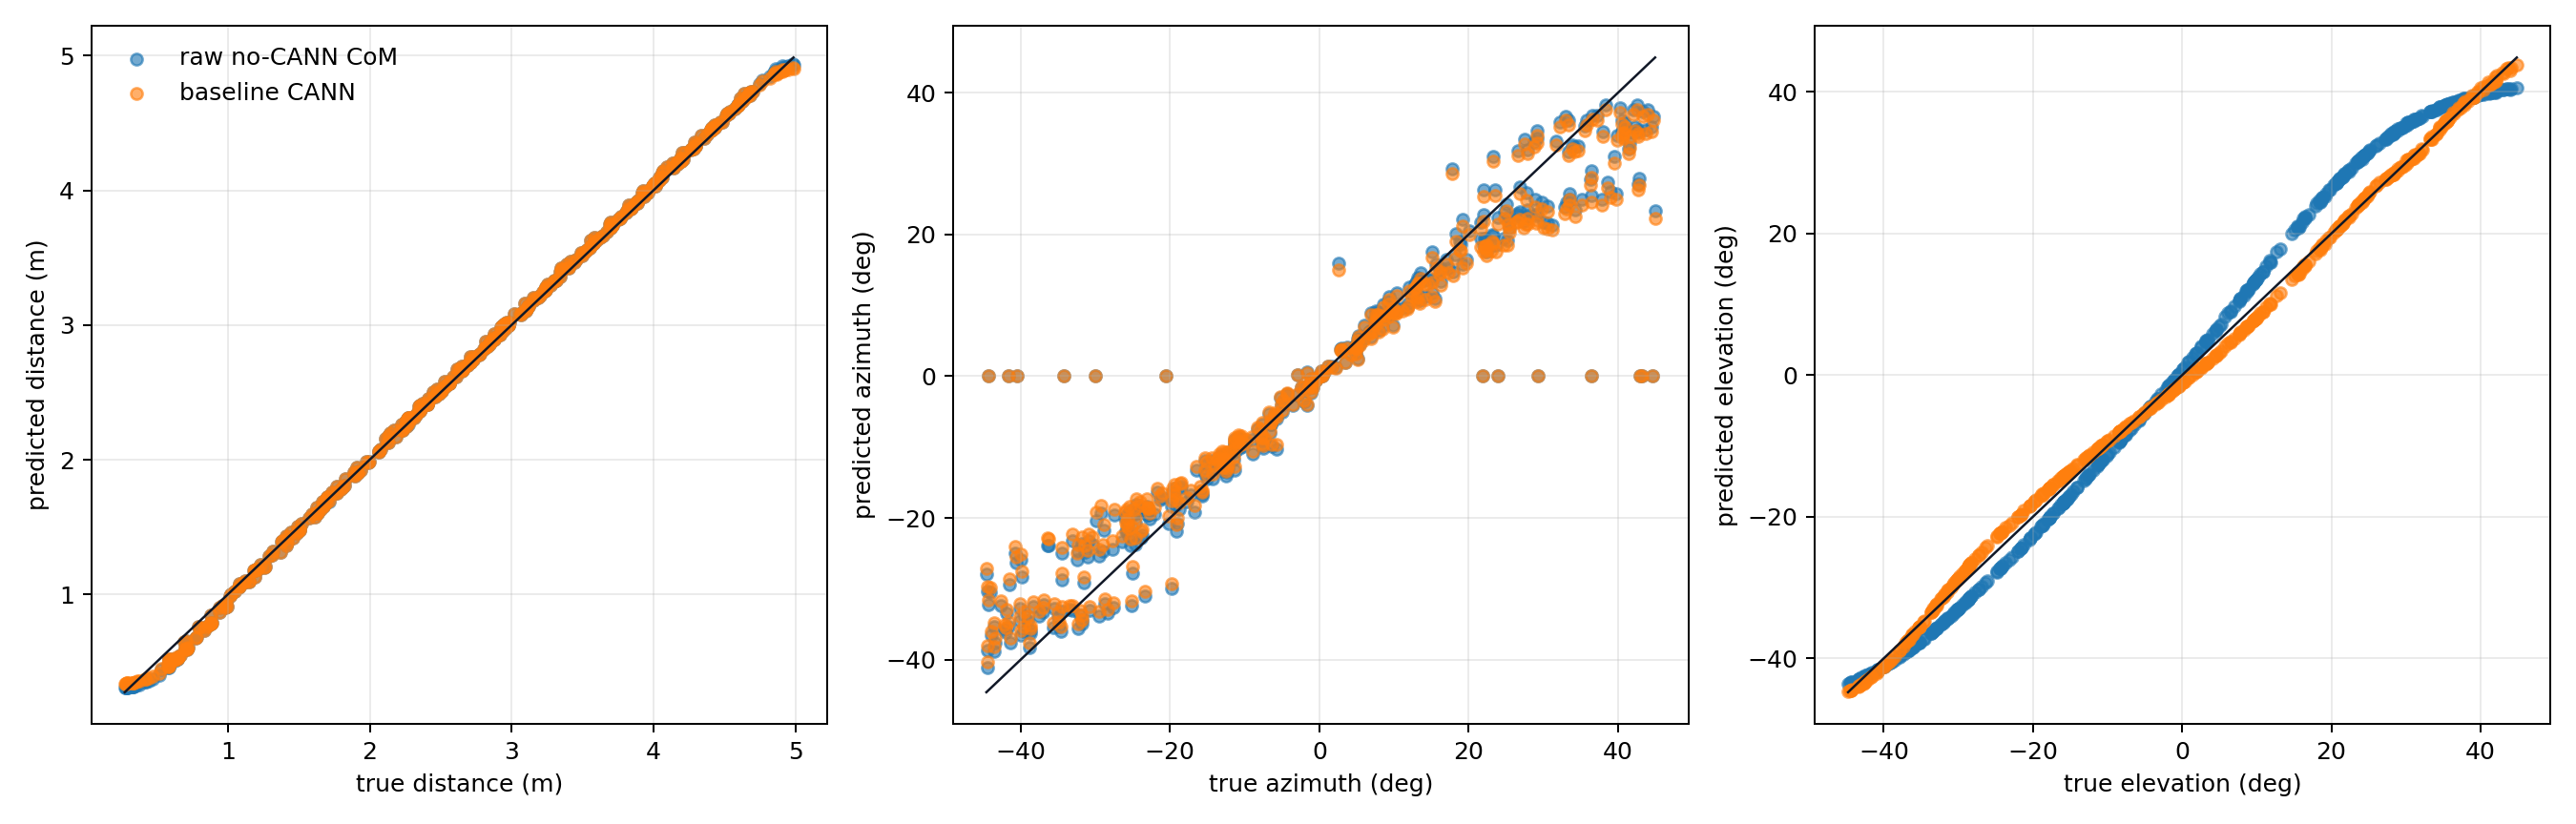

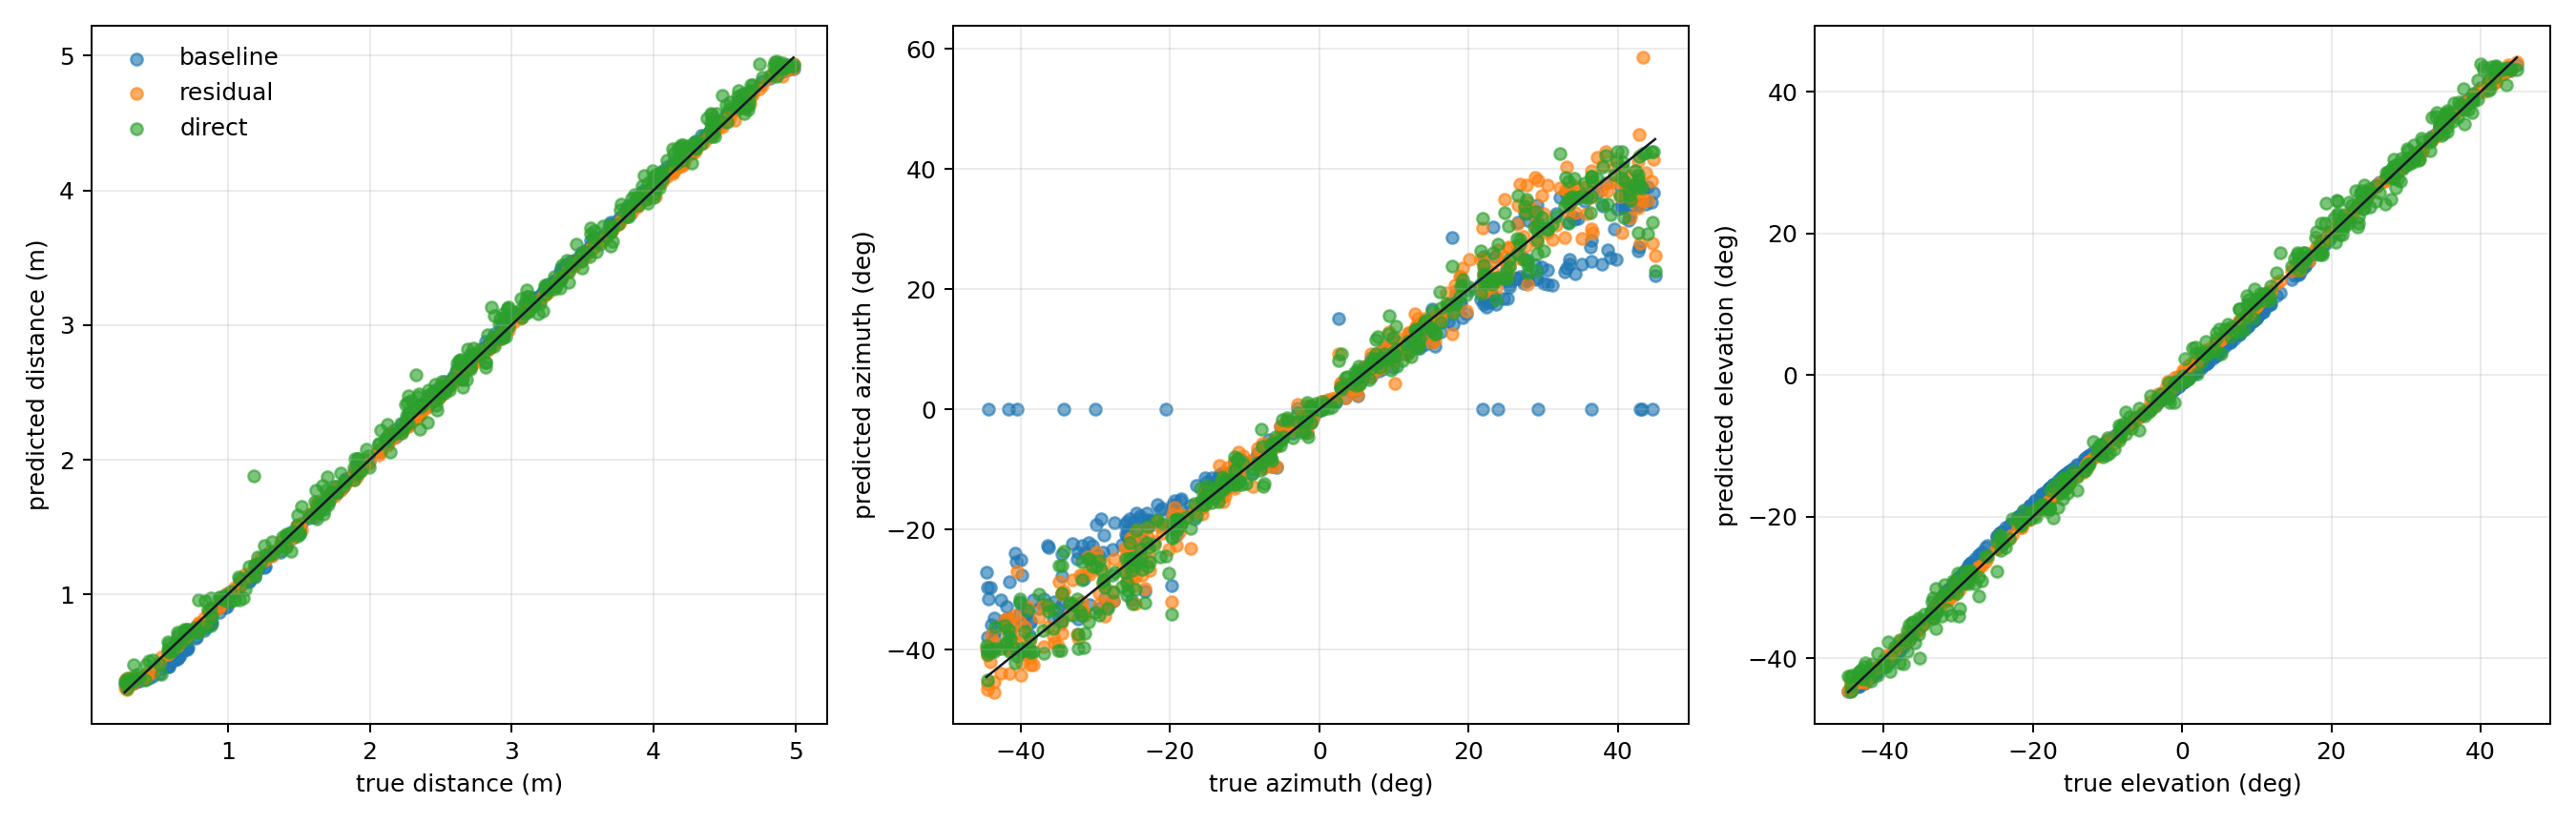

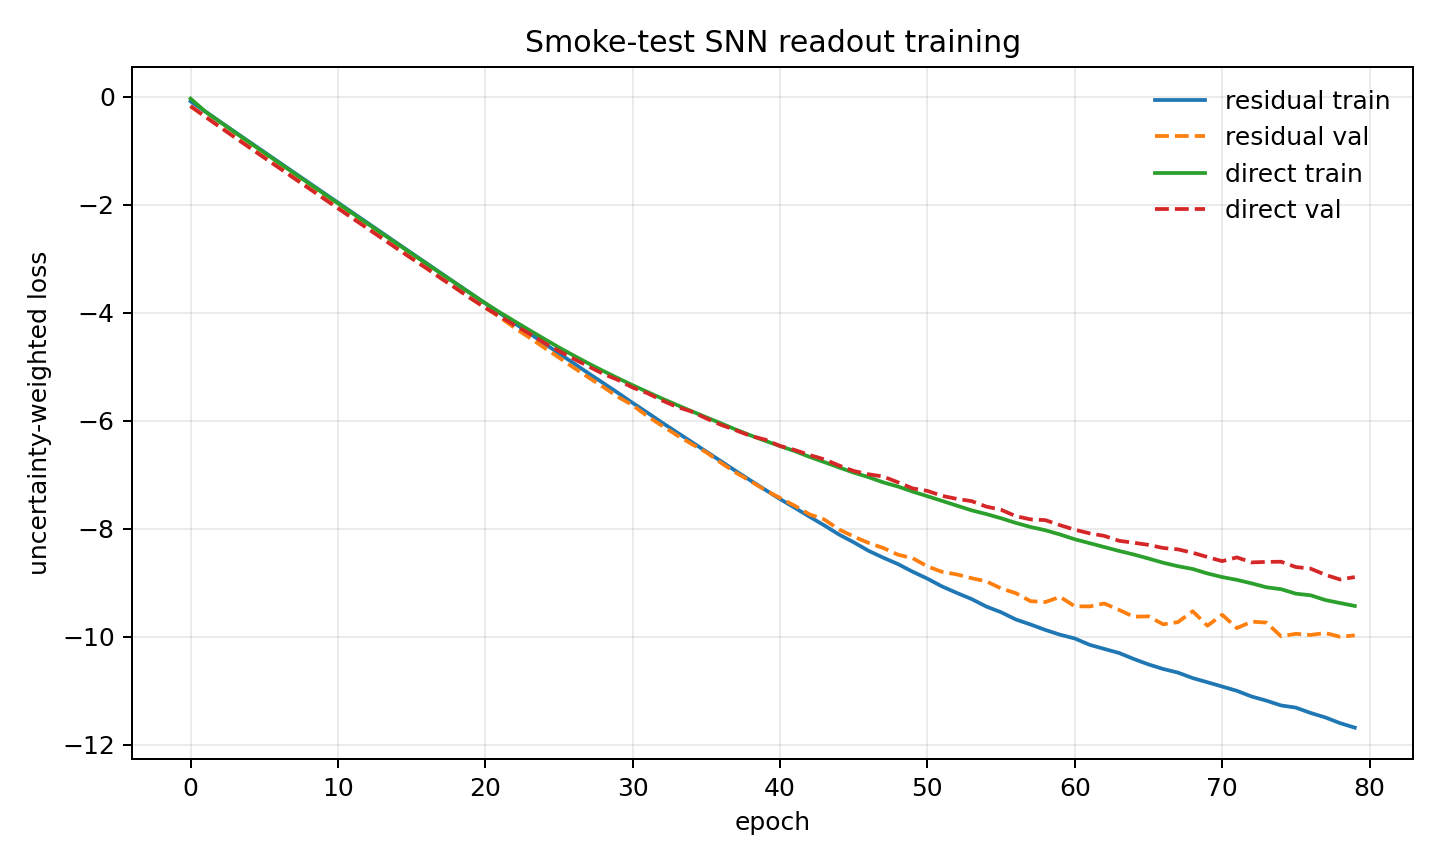

In [10]:
display_png('final_model/outputs/trainable_readout/figures/train2000_val400_test400/raw_vs_baseline_scatter.png', width=900)
display_png('final_model/outputs/trainable_readout/figures/train2000_val400_test400/test_prediction_scatter.png', width=900)
display_png('final_model/outputs/trainable_readout/figures/train2000_val400_test400/training_curves.png', width=900)

## 4. Clean Test Predictions From The Cached Arrays

The JSON reports contain aggregate metrics. The `.npz` prediction caches contain the actual held-out test predictions. The next cell reloads those arrays and plots distance/azimuth/elevation scatter plots for the clean fixed baseline, direct SNN, and residual SNN.

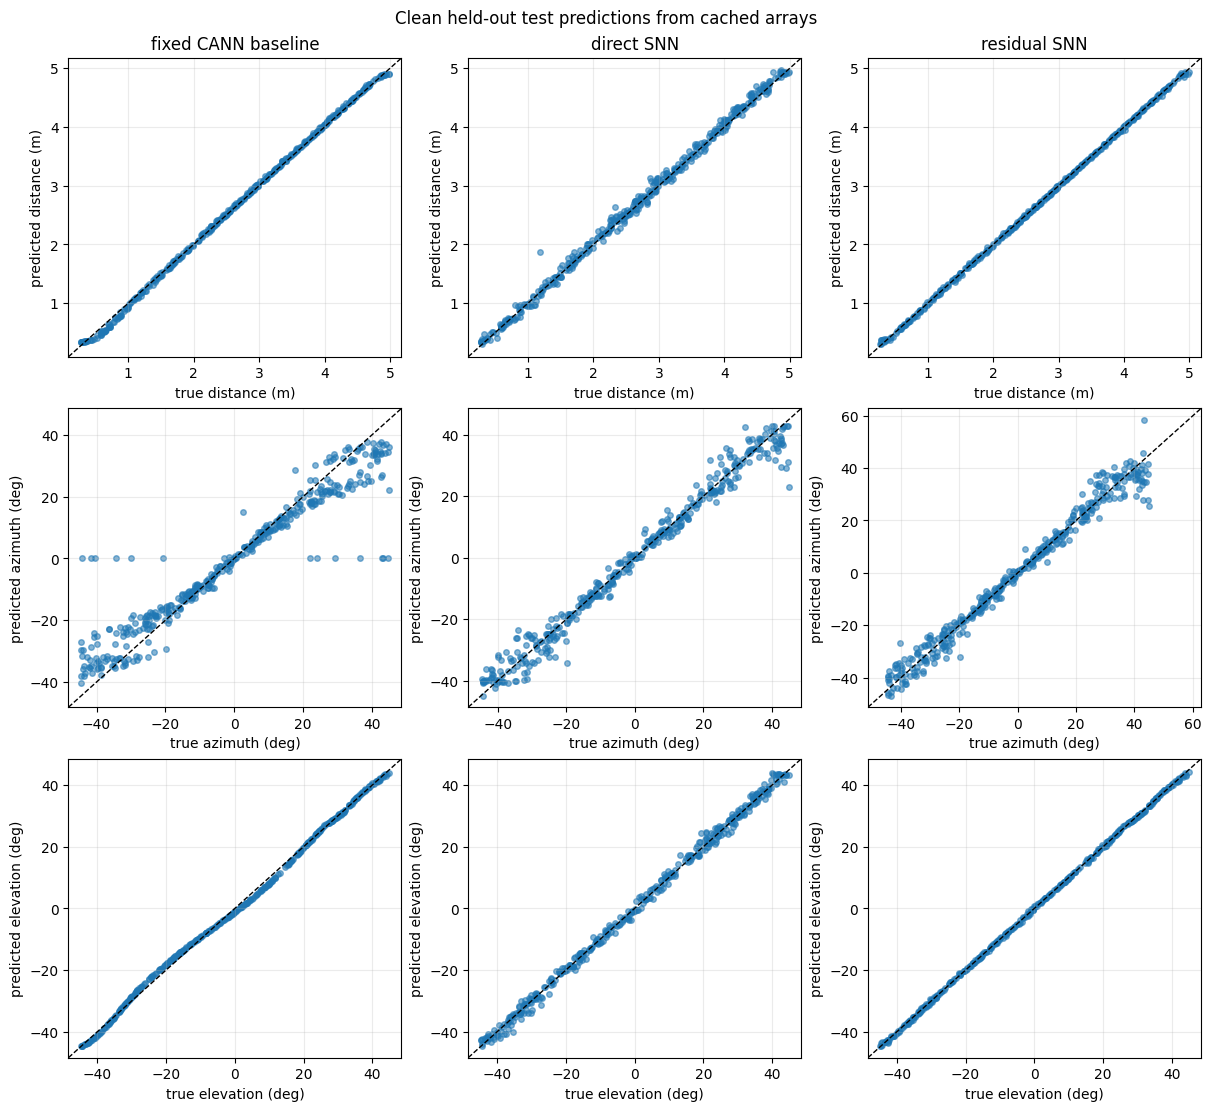

In [11]:
clean_predictions = load_npz(ARTIFACTS['clean_readout_predictions'])
true = clean_predictions['true_coordinates']

plot_models = {
    'fixed CANN baseline': clean_predictions['baseline_coordinates'],
    'direct SNN': clean_predictions['direct_coordinates'],
    'residual SNN': clean_predictions['residual_coordinates'],
}
coord_names = [('distance', 'm'), ('azimuth', 'deg'), ('elevation', 'deg')]

fig, axes = plt.subplots(3, 3, figsize=(12, 11), constrained_layout=True)
for col, (model_name, pred) in enumerate(plot_models.items()):
    for row, (coord, unit) in enumerate(coord_names):
        ax = axes[row, col]
        x = true[:, row]
        y = pred[:, row]
        lo = float(min(x.min(), y.min()))
        hi = float(max(x.max(), y.max()))
        pad = 0.04 * (hi - lo if hi > lo else 1.0)
        ax.scatter(x, y, s=16, alpha=0.55)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', linewidth=1)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_title(model_name if row == 0 else '')
        ax.set_xlabel(f'true {coord} ({unit})')
        ax.set_ylabel(f'predicted {coord} ({unit})')
        ax.grid(alpha=0.25)
fig.suptitle('Clean held-out test predictions from cached arrays')
plt.show()

## 5. Feature Importance

The reports include two diagnostics:

- first-layer weight magnitudes grouped by input feature group,
- zero-ablation sensitivity, measured by removing one normalised feature group at test time.

These are not a perfect causal explanation, but they help show that the residual model uses the wider population representation rather than only the three scalar CANN coordinates.

,residual first-layer weight,residual zero-ablation Δ combined,direct first-layer weight,direct zero-ablation Δ combined
feature group,,,,
raw_distance_population,0.16024,0.00405,0.15639,0.03560
raw_azimuth_itd_population,0.14515,0.01152,0.11832,0.02420
raw_azimuth_ild_population,0.14933,0.01068,0.13336,0.02390
raw_elevation_population,0.17681,0.00526,0.18064,0.11388
cann_readouts,0.16172,0.00002,0.19232,-0.00007
confidence_features,0.20674,0.00115,0.21897,0.00509


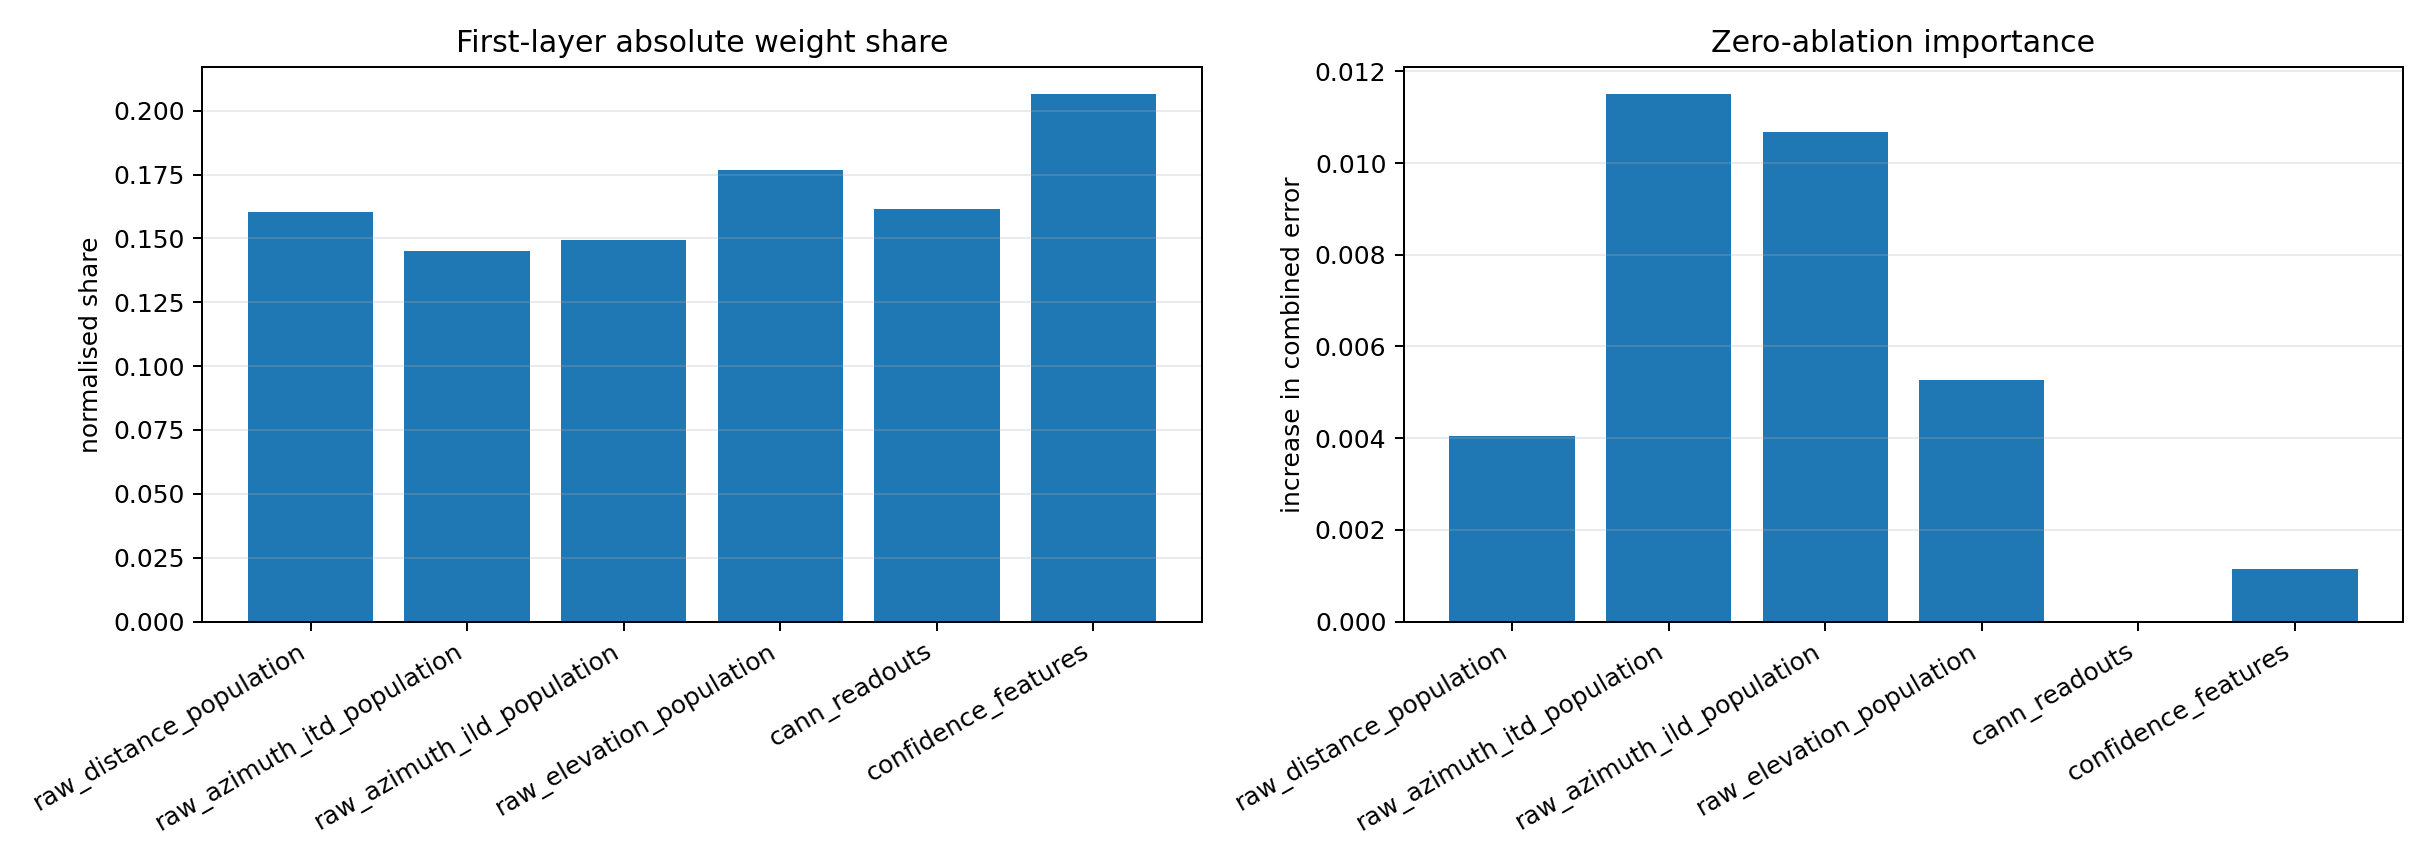

In [12]:
clean_readout = readout_results['clean']
importance_rows = []
for group in feature_groups:
    importance_rows.append({
        'feature group': group,
        'residual first-layer weight': clean_readout['residual_weight_importance'].get(group, np.nan),
        'residual zero-ablation Δ combined': clean_readout['residual_ablation_importance'].get(group, np.nan),
        'direct first-layer weight': clean_readout['direct_weight_importance'].get(group, np.nan),
        'direct zero-ablation Δ combined': clean_readout['direct_ablation_importance'].get(group, np.nan),
    })

if pd is not None:
    display(pd.DataFrame(importance_rows).set_index('feature group').round(5))
else:
    display(importance_rows)

display_png('final_model/outputs/trainable_readout/figures/train2000_val400_test400/residual_feature_importance.png', width=850)

## 6. Input-Only SNN Baselines

The input-only controls test whether the final SNN succeeds merely because a trainable network was added. These baselines use the same target and broadly similar readout structure, but do not receive the hand-designed cue-specific pathway populations.

The raw waveform baseline receives flattened binaural waveform features. The cochlear-raster baseline receives time-binned cochlear spike counts.

In [13]:
input_result_paths = {
    'clean': ARTIFACTS['clean_input_baseline_results'],
    'environment noise': ARTIFACTS['noise_input_baseline_results'],
    'noise + delayed echoes': ARTIFACTS['reverb_input_baseline_results'],
}
input_results = {name: load_json(path) for name, path in input_result_paths.items()}

input_rows = []
for condition, payload in input_results.items():
    for model_name, metrics in payload['test_metrics'].items():
        row = metric_row(model_name, metrics)
        row['condition'] = condition
        input_rows.append(row)

if pd is not None:
    display(pd.DataFrame(input_rows).set_index(['condition', 'model']).round(4))
else:
    display(input_rows)

distance MAE (m)  \
condition              model                                         
clean                  raw_waveform_projected               0.2954   
                       raw_waveform_direct                  0.8053   
                       cochlear_raster_projected            0.0677   
                       cochlear_raster_direct               0.0651   
environment noise      raw_waveform_projected               0.4113   
                       raw_waveform_direct                  0.9794   
                       cochlear_raster_projected            0.0733   
                       cochlear_raster_direct               0.0699   
noise + delayed echoes raw_waveform_projected               0.3945   
                       raw_waveform_direct                  0.9414   
                       cochlear_raster_projected            0.0772   
                       cochlear_raster_direct               0.0632   

                                                  azimuth MAE (deg)  \
condition              model                                          
clean                  raw_waveform_projected               21.1598   
                       raw_waveform_direct                  21.5796   
                       cochlear_raster_projected             4.2923   
                       cochlear_raster_direct                6.0333   
environment noise      raw_waveform_projected               23.1062   
                       raw_waveform_direct                  23.8468   
                       cochlear_raster_projected             6.2349   
                       cochlear_raster_direct                5.9914   
noise + delayed echoes raw_waveform_projected               22.3491   
                       raw_waveform_direct                  21.9897   
                       cochlear_raster_projected             5.4146   
                       cochlear_raster_direct                5.8997   

                                                  elevation MAE (deg)  \
condition              model                                            
clean                  raw_waveform_projected                 20.2206   
                       raw_waveform_direct                    22.8546   
                       cochlear_raster_projected               6.2821   
                       cochlear_raster_direct                  7.1777   
environment noise      raw_waveform_projected                 22.6674   
                       raw_waveform_direct                    23.8356   
                       cochlear_raster_projected               4.9870   
                       cochlear_raster_direct                  4.6784   
noise + delayed echoes raw_waveform_projected                 22.3074   
                       raw_waveform_direct                    22.4713   
                       cochlear_raster_projected               3.8113   
                       cochlear_raster_direct                  4.7039   

                                                  Euclidean MAE (m)  \
condition              model                                          
clean                  raw_waveform_projected                1.4882   
                       raw_waveform_direct                   1.8587   
                       cochlear_raster_projected             0.2580   
                       cochlear_raster_direct                0.3873   
environment noise      raw_waveform_projected                1.7410   
                       raw_waveform_direct                   2.0059   
                       cochlear_raster_projected             0.2977   
                       cochlear_raster_direct                0.2830   
noise + delayed echoes raw_waveform_projected                1.7023   
                       raw_waveform_direct                   1.9033   
                       cochlear_raster_projected             0.3001   
                       cochlear_raster_direct                0.2685   

                                                  combin

Raw waveform direct features: (2800, 4608)
Raw waveform projected features: (2800, 474)
Cochlear raster direct features: (2800, 960)
Cochlear raster projected features: (2800, 474)
Targets: (2800, 3)
Setup: {'splits': {'train': 2000, 'val': 400, 'test': 400}, 'dataset_seed': 8101, 'projection_seed': 42404, 'feature_dim': 474, 'cochlear_time_bins': 10, 'raw_high_dim': 4608, 'cochlear_high_dim': 960, 'acoustic_mode': 'clean', 'noise_label': 'clean', 'noise_std': 0.0, 'environment_noise_db': 0.0, 'environment_reverb': False}


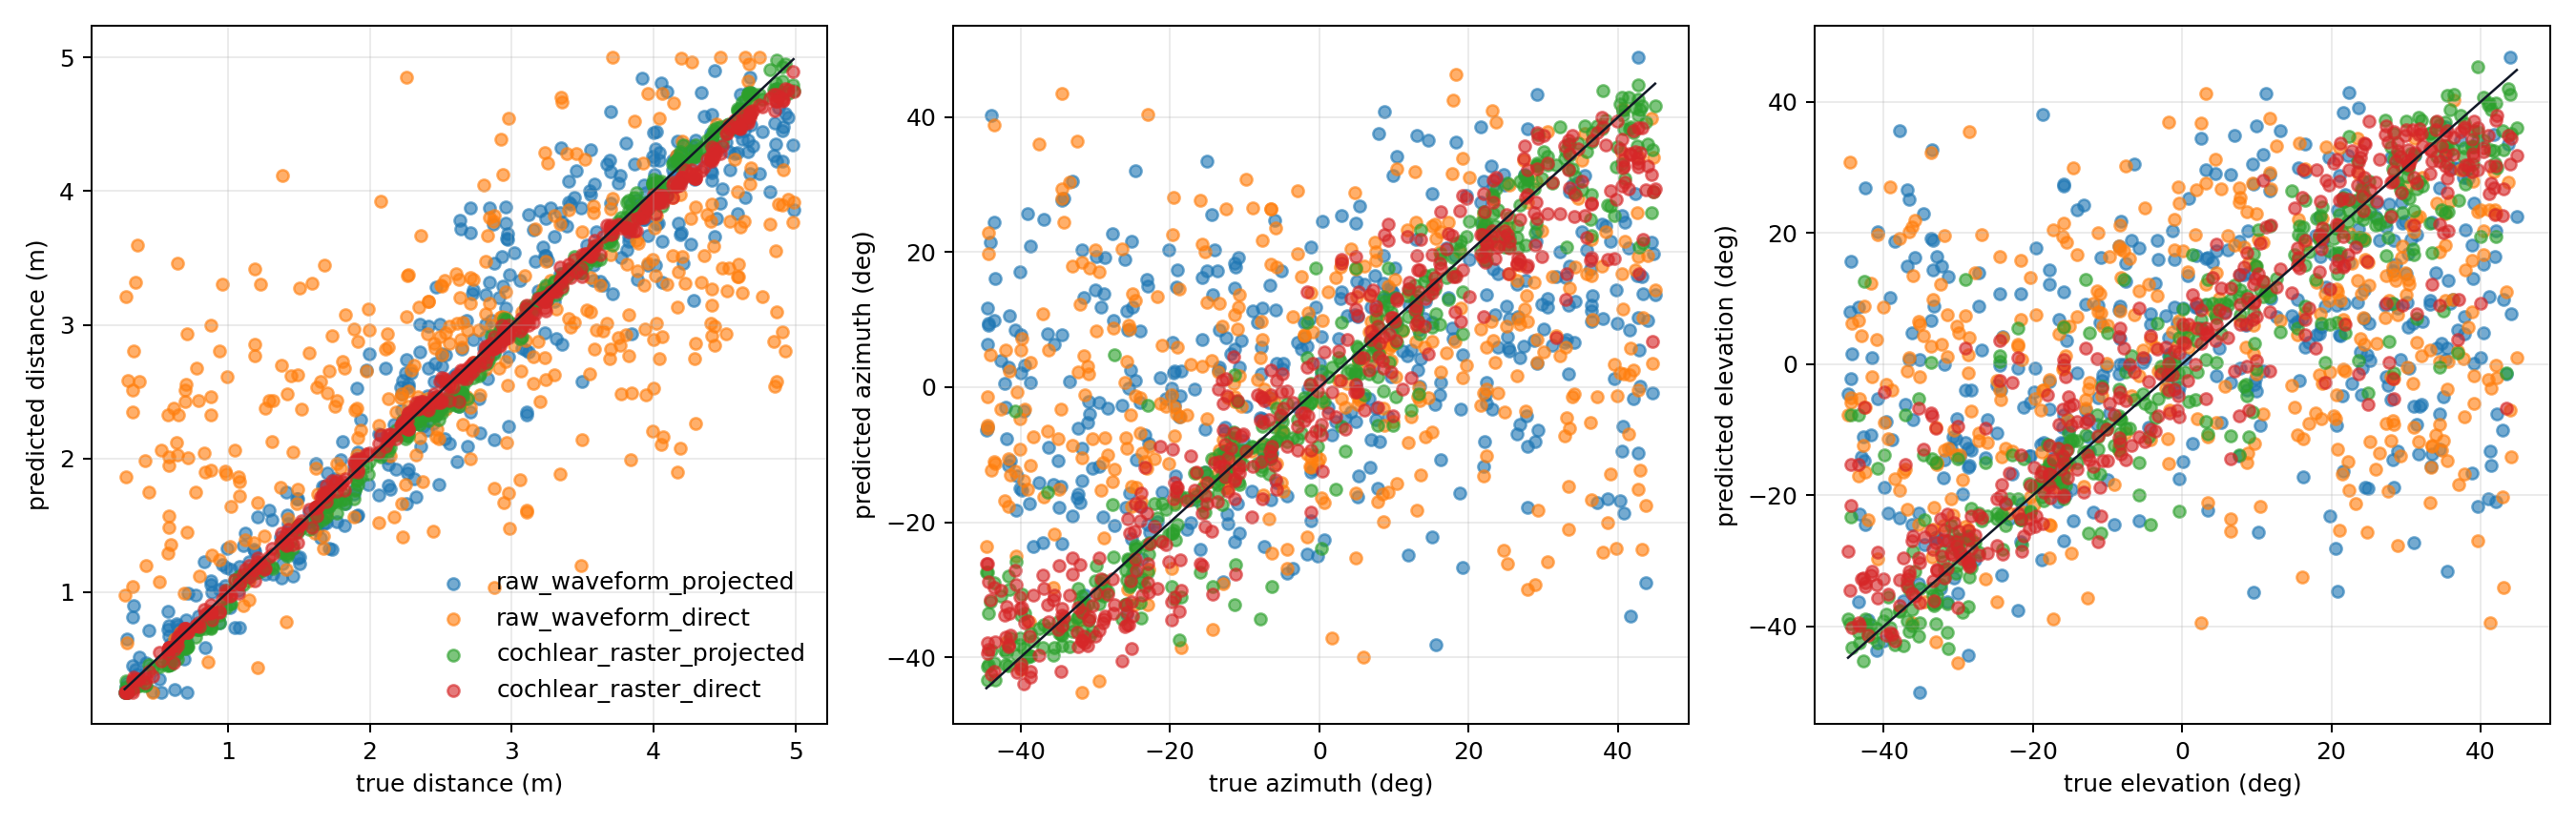

In [14]:
input_cache = load_npz(ARTIFACTS['clean_input_baseline_cache'])
print('Raw waveform direct features:', input_cache['raw_waveform_direct_features'].shape)
print('Raw waveform projected features:', input_cache['raw_waveform_projected_features'].shape)
print('Cochlear raster direct features:', input_cache['cochlear_raster_direct_features'].shape)
print('Cochlear raster projected features:', input_cache['cochlear_raster_projected_features'].shape)
print('Targets:', input_cache['true_coordinates'].shape)
print('Setup:', input_cache['setup'].item())

display_png('final_model/outputs/trainable_input_baselines/figures/train2000_val400_test400/prediction_scatter.png', width=900)

## 7. Final Comparison

This table combines the main clean-condition comparison: raw waveform SNN, cochlear-raster SNN, fixed pathway/CANN baseline, direct pathway-feature SNN, and residual pathway-feature SNN.

,distance MAE (m),azimuth MAE (deg),elevation MAE (deg),Euclidean MAE (m),combined error
model,,,,,
raw waveform SNN direct,0.8053,21.5796,22.8546,1.8587,0.3828
cochlear-raster SNN projected,0.0677,4.2923,6.2821,0.2580,0.0828
fixed pathway/CANN,0.0366,4.9249,0.9100,0.2435,0.0457
direct pathway-feature SNN,0.0624,2.4491,1.1326,0.1612,0.0307
residual pathway-feature SNN,0.0139,2.6188,0.2668,0.1247,0.0223


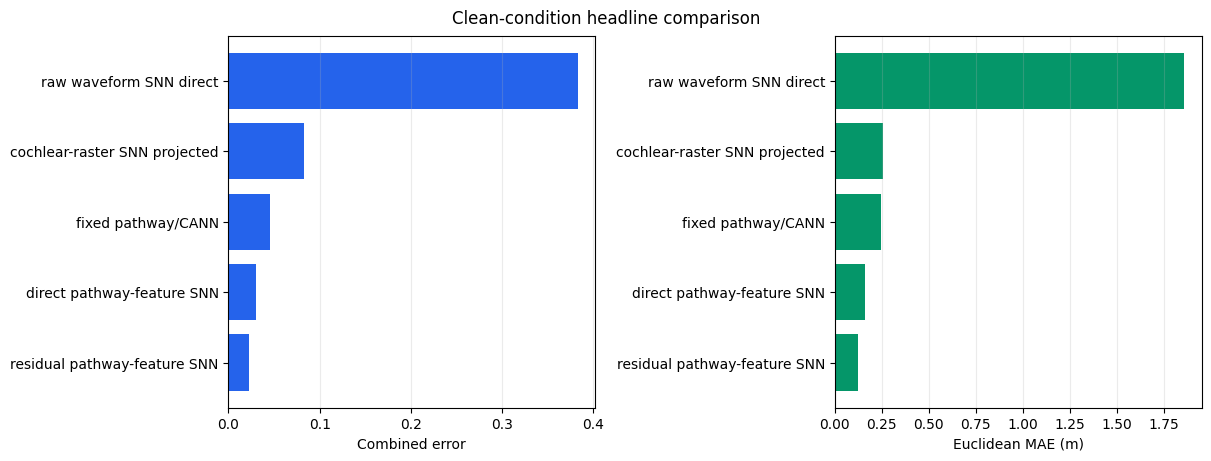

In [15]:
clean_input = input_results['clean']['test_metrics']
clean_pathway = readout_results['clean']['test_metrics']
comparison_rows = [
    metric_row('raw waveform SNN direct', clean_input['raw_waveform_direct']),
    metric_row('cochlear-raster SNN projected', clean_input['cochlear_raster_projected']),
    metric_row('fixed pathway/CANN', clean_pathway['baseline']),
    metric_row('direct pathway-feature SNN', clean_pathway['direct']),
    metric_row('residual pathway-feature SNN', clean_pathway['residual']),
]

if pd is not None:
    comparison_df = pd.DataFrame(comparison_rows).set_index('model').round(4)
    display(comparison_df)
else:
    display(comparison_rows)

# Bar plot for combined error and Euclidean MAE.
labels = [row['model'] for row in comparison_rows]
combined = [row['combined error'] for row in comparison_rows]
euclidean = [row['Euclidean MAE (m)'] for row in comparison_rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].barh(labels, combined, color='#2563eb')
axes[0].set_xlabel('Combined error')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.25)
axes[1].barh(labels, euclidean, color='#059669')
axes[1].set_xlabel('Euclidean MAE (m)')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.25)
fig.suptitle('Clean-condition headline comparison')
plt.show()

## 8. Optional: Live Single-Condition Smoke Run

The cells above reproduce the final results from the full cached artifacts. The optional cell below calls the real integrated fixed-model function on a very small target set. This is useful for checking that imports and pathway wiring still work, but it is not intended to reproduce the report metrics because it uses only a tiny number of samples.

Set `RUN_LIVE_SMOKE = True` to execute it.

In [16]:
RUN_LIVE_SMOKE = False

if RUN_LIVE_SMOKE:
    from final_model.experiments import final_model_results as final

    targets = final.random_targets(
        samples=2,
        min_distance_m=0.25,
        max_distance_m=5.0,
        azimuth_limit_deg=45.0,
        elevation_limit_deg=45.0,
        seed=123,
    )
    smoke = final.run_integrated_condition(
        name='notebook_smoke',
        targets=targets,
        channels=final.BASE_CHANNELS,
        distance_bins=final.BASE_DISTANCE_BINS,
        angular_bins=final.BASE_READOUT_BINS,
        min_distance_m=0.25,
        max_distance_m=5.0,
        azimuth_limit_deg=45.0,
        elevation_limit_deg=45.0,
    )
    display(smoke['metrics'])
else:
    print('Skipped live smoke run. Set RUN_LIVE_SMOKE = True to execute the real fixed pipeline on two samples.')

Skipped live smoke run. Set RUN_LIVE_SMOKE = True to execute the real fixed pipeline on two samples.


## Takeaways

- The fixed pathways convert the echo into interpretable distance, azimuth, and elevation population codes.
- The CANN/readout stage receives completed pathway populations and runs recurrent readout dynamics; it is not currently a continuously driven temporal tracker.
- The final trainable readout uses cached pathway features repeated across its internal SNN timesteps.
- The residual SNN is the strongest final architecture because it preserves the fixed pathway estimate and learns systematic corrections from the wider population feature set.
- The input-only SNN baselines are important controls: they show that performance is not simply due to adding any trainable SNN.